# Paradoks Zygmunta Hajzera
## Matematyczna strategia zdawania testów

In [ ]:
# Pakiety
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

### Funkcja tworząca test

In [ ]:
def test_initiator(n = 10):
    test = np.zeros((n, 3))
    correct_answer_position = []
    for i in range(n):
        random_number =  np.random.choice(range(3))
        test[i, random_number] = 1
        correct_answer_position.append(random_number)
    correct_answer_position = np.array(correct_answer_position)
    return test, correct_answer_position

### Funkcja wybierająca odpowiedzi losowo

In [ ]:
def random_answers(test):
    questions = test[0]
    answers = []
    for i in range(questions.shape[0]):
        ans = np.random.choice(questions[i,:])
        answers.append(ans)
    return np.array(answers)

### Funkcja wybierająca odpowiedzi według strategii PZH

In [ ]:
def pzh_answers(test, p):
    questions = test[0]
    correct_answer_position = test[1]
    answers = []
    for i in range(questions.shape[0]):
        del_option = np.random.choice(range(3))
        corr_position = correct_answer_position[i]
        probs =  np.zeros(3)
        probs[corr_position] = p
        probs[del_option] = 0
        probs[list({0,1,2} - {del_option, corr_position})[0]] = 1 - p
        if np.sum(probs) != 1:
            probs = np.full(3, 0.5)
            probs[del_option] = 0
        ans = np.random.choice(list(questions[i,:]), p = list(probs))
        answers.append(ans)
    return np.array(answers)

### Eksperyment

In [ ]:
control_group = np.zeros((100, 100))
experiment_group = np.zeros((100, 100))
for n in tqdm(range(1, 101)):
    for m in range(1, 101):
        control_group[n - 1,m - 1] = np.mean(random_answers(test_initiator(n = n)))
        experiment_group[n - 1,m - 1] = np.mean(pzh_answers(test_initiator(n = n), p = 1))

  0%|          | 0/100 [00:00<?, ?it/s]

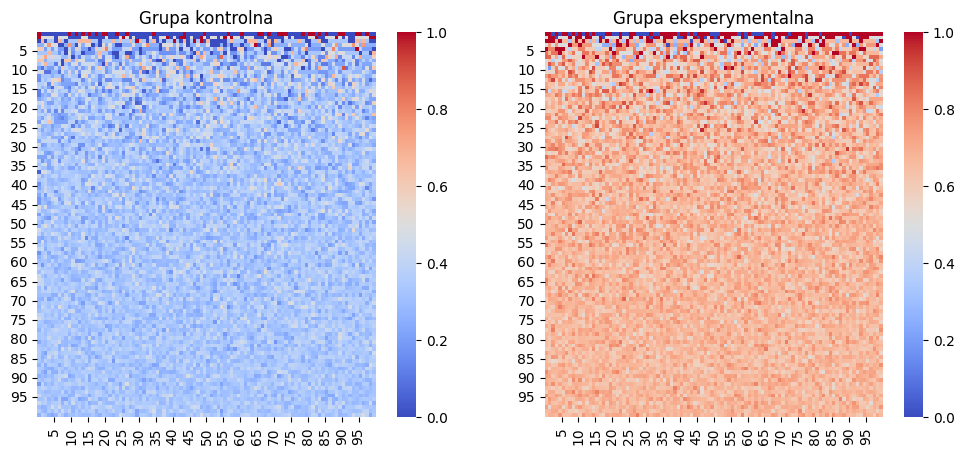

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Grupa kontrolna

sns.heatmap(control_group,
            cmap="coolwarm",
            annot=False, ax=axes[0])
axes[0].set_xticks(np.arange(5, 100, 5))
axes[0].set_xticklabels(np.arange(5, 100, 5))
axes[0].set_yticks(np.arange(5, 100, 5))
axes[0].set_yticklabels(np.arange(5, 100, 5))
axes[0].set_title("Grupa kontrolna")

# Grupa eksperymentalna

sns.heatmap(experiment_group,
            cmap="coolwarm",
            annot=False,
            ax=axes[1])
axes[1].set_xticks(np.arange(5, 100, 5))
axes[1].set_xticklabels(np.arange(5, 100, 5))
axes[1].set_yticks(np.arange(5, 100, 5))
axes[1].set_yticklabels(np.arange(5, 100, 5))
axes[1].set_title("Grupa eksperymentalna")

plt.show()

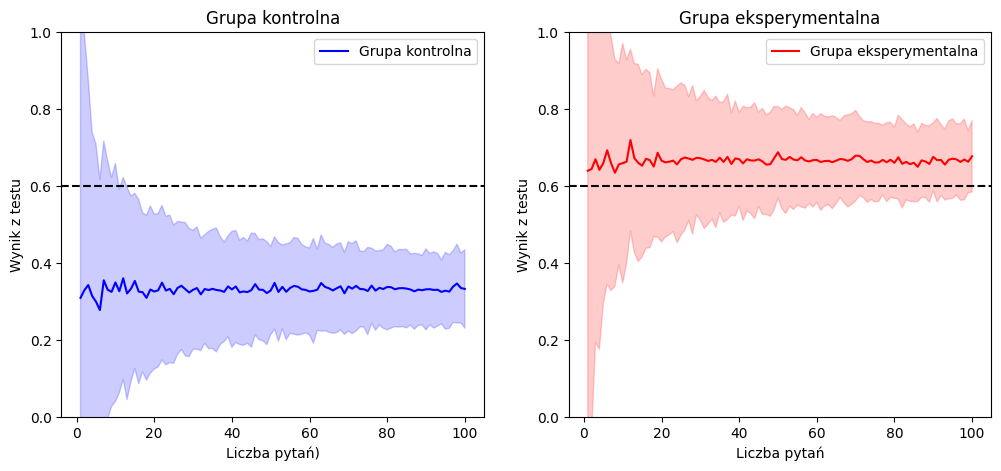

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 wiersz, 2 kolumny

x = np.arange(1,101)

# Grupa kontrolna

y1 = np.mean(control_group, axis = 1)
y1_min = np.mean(control_group, axis = 1) - 1.96*np.std(control_group, axis = 1)
y1_max = np.mean(control_group, axis = 1) + 1.96*np.std(control_group, axis = 1)

axes[0].plot(x, y1, label="Grupa kontrolna", color='b')
axes[0].fill_between(x, y1_min, y1_max, color='b', alpha=0.2)
axes[0].set_title("Grupa kontrolna")
axes[0].set_xlabel("Liczba pytań)")
axes[0].set_ylabel("Wynik z testu")
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.6, color='black', linestyle='--')
axes[0].legend()

# Grupa eksperymentalna

y2 = np.mean(experiment_group, axis = 1)
y2_min = np.mean(experiment_group, axis = 1) - 1.96*np.std(experiment_group, axis = 1)
y2_max = np.mean(experiment_group, axis = 1) + 1.96*np.std(experiment_group, axis = 1)

axes[1].plot(x, y2, label="Grupa eksperymentalna", color='r')
axes[1].fill_between(x, y2_min, y2_max, color='r', alpha=0.2)
axes[1].set_title("Grupa eksperymentalna")
axes[1].set_xlabel("Liczba pytań")
axes[1].set_ylabel("Wynik z testu")
axes[1].set_ylim(0, 1)
axes[1].axhline(y=0.6, color='black', linestyle='--')
axes[1].legend()

plt.show()

In [ ]:
number_of_questions = 30

t_stat, p_value = ttest_ind(control_group[number_of_questions - 1,:],
                            experiment_group[number_of_questions - 1,:])

print(f"Statystyka t: {t_stat:.4f}")
print(f"p-wartość: {p_value:.4f}")

Statystyka t: -29.8764
p-wartość: 0.0000


  0%|          | 0/13 [00:00<?, ?it/s]

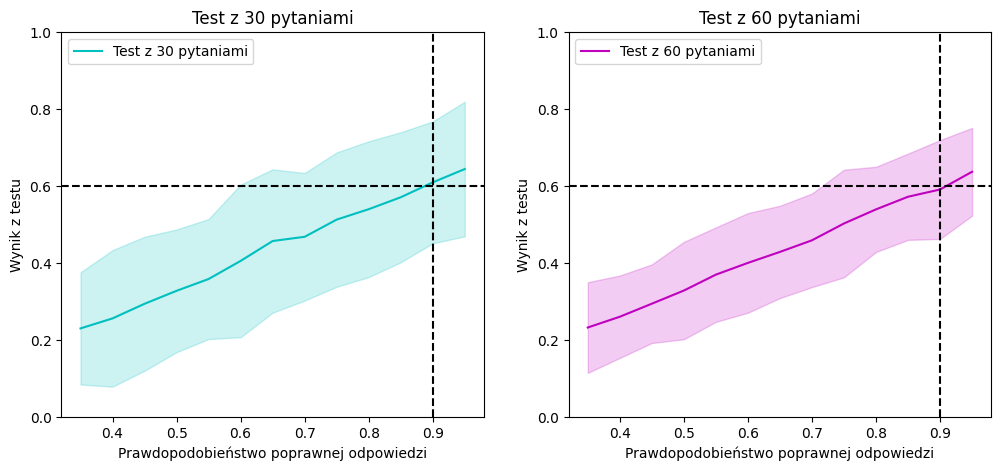

In [ ]:
different_knowlegde_30 = []
std_err_30 = []
different_knowlegde_60 = []
std_err_60 = []
probsy = np.arange(0.35, 1, 0.05)
x_30 = []
x_60 = []
for i in tqdm(probsy):
    x_30 = []
    x_60 = []
    for j in range(100):
        x_30.append(np.mean(pzh_answers(test_initiator(n = 30), p = i)))
        x_60.append(np.mean(pzh_answers(test_initiator(n = 60), p = i)))
    different_knowlegde_30.append(np.mean(x_30))
    std_err_30.append(np.std(x_30))
    different_knowlegde_60.append(np.mean(x_60))
    std_err_60.append(np.std(x_60))


fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 wiersz, 2 kolumny

x = probsy

# Test z 30 pytaniami

y1 = np.array(different_knowlegde_30)
y1_min = y1 - 1.96*np.array(std_err_30)
y1_max = y1 + 1.96*np.array(std_err_30)

axes[0].plot(x, y1, label="Test z 30 pytaniami", color='c')
axes[0].fill_between(x, y1_min, y1_max, color='c', alpha=0.2)
axes[0].set_title("Test z 30 pytaniami")
axes[0].set_xlabel("Prawdopodobieństwo poprawnej odpowiedzi")
axes[0].set_ylabel("Wynik z testu")
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.6, color='black', linestyle='--')
axes[0].axvline(x=0.9, color='black', linestyle='--')
axes[0].legend()

# Test z 60 pytaniami

y2 = np.array(different_knowlegde_60)
y2_min = y2 - 1.96*np.array(std_err_60)
y2_max = y2 + 1.96*np.array(std_err_60)

axes[1].plot(x, y2, label="Test z 60 pytaniami", color='m')
axes[1].fill_between(x, y2_min, y2_max, color='m', alpha=0.2)
axes[1].set_title("Test z 60 pytaniami")
axes[1].set_xlabel("Prawdopodobieństwo poprawnej odpowiedzi")
axes[1].set_ylabel("Wynik z testu")
axes[1].set_ylim(0, 1)
axes[1].axhline(y=0.6, color='black', linestyle='--')
axes[1].axvline(x=0.9, color='black', linestyle='--')
axes[1].legend()

plt.show()

# Zadania

**Zadanie 1.**

Proszę napisać funkcję tworzącą modelu testu składającego się z $n$ pytań oraz $3$ wariantów odpowiedzi.

**Zadanie 2.**

Proszę napisać funkcję, która losowo wybiera odpowiedź.

**Zadanie 3.**

Proszę napisać funkcję, która wybiera odpowiedź według strategii PZH.

**Zadanie 4.**

Proszę wykonać eksperyment, którego wynikiem będą dwie macierze:
1. Macierz grupy kontrolnej (losowy wybór odpowiedzi);
2. Macierz grupy eksperymentalnej (wybór odpowiedzi według strategii PZH).

W obu przypadkach numer wiersza jest liczbą pytań w teście, a numer kolumny jest numerem powtórzenia.
Eksperyment proszę wykonać dla testów mających 1, 2, 3, ..., 100 pytań, po sto powtórzeń w każdym przypadku.

**Zadanie 5.**

Proszę narysować mapy gorąca na podstawie macierzy z zadania 4.

**Zadanie 6.**

Proszę narysować dwa wykresy liniowe (dla grupy kontrolnej i dla grupy eksperymentalnej), gdzie:
1. Na osi OX jest liczba pytań w teście;
2. Na osi OY jest średni wynik testu;
3. Wokół obu linii proszę narysować 95% przedziały ufności.